In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.8 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/patient_list.csv")
print(len(df))
df.head()

774


,patient_id,region,patient_path,cbct_path,ct_path,mask_path,has_cbct,has_ct,has_mask
0,2ABA002,AB,data/Task2/AB/2ABA002,data/Task2/AB/2ABA002/cbct.mha,data/Task2/AB/2ABA002/ct.mha,data/Task2/AB/2ABA002/mask.mha,True,True,True
1,2ABA005,AB,data/Task2/AB/2ABA005,data/Task2/AB/2ABA005/cbct.mha,data/Task2/AB/2ABA005/ct.mha,data/Task2/AB/2ABA005/mask.mha,True,True,True
2,2ABA006,AB,data/Task2/AB/2ABA006,data/Task2/AB/2ABA006/cbct.mha,data/Task2/AB/2ABA006/ct.mha,data/Task2/AB/2ABA006/mask.mha,True,True,True
3,2ABA008,AB,data/Task2/AB/2ABA008,data/Task2/AB/2ABA008/cbct.mha,data/Task2/AB/2ABA008/ct.mha,data/Task2/AB/2ABA008/mask.mha,True,True,True
4,2ABA009,AB,data/Task2/AB/2ABA009,data/Task2/AB/2ABA009/cbct.mha,data/Task2/AB/2ABA009/ct.mha,data/Task2/AB/2ABA009/mask.mha,True,True,True


In [5]:
%%writefile src/preprocessing.py
import numpy as np
import SimpleITK as sitk


def read_mha(path):

    image = sitk.ReadImage(path)
    array = sitk.GetArrayFromImage(image)
    spacing = image.GetSpacing()
    origin = image.GetOrigin()
    direction = image.GetDirection()
    return image, array, spacing, origin, direction


def clip_hu(image, min_hu=-1000, max_hu=1600):
    return np.clip(image, min_hu, max_hu)


def normalize_hu(image, min_hu=-1000, max_hu=1600):

    image = clip_hu(image, min_hu, max_hu)
    image = 2.0 * (image - min_hu) / (max_hu - min_hu) - 1.0
    return image.astype(np.float32)


def denormalize_hu(image_norm, min_hu=-1000, max_hu=1600):

    image = (image_norm + 1.0) / 2.0
    image = image * (max_hu - min_hu) + min_hu
    return image.astype(np.float32)


def prepare_mask(mask):

    return (mask > 0).astype(np.float32)


def apply_mask(image, mask, background_value=-1000):

    image_masked = image.copy()
    image_masked[mask == 0] = background_value
    return image_masked


def center_crop_or_pad_2d(image, target_size=320, pad_value=0):

    h, w = image.shape

    crop_y_start = max((h - target_size) // 2, 0)
    crop_x_start = max((w - target_size) // 2, 0)

    crop_y_end = crop_y_start + min(h, target_size)
    crop_x_end = crop_x_start + min(w, target_size)

    cropped = image[crop_y_start:crop_y_end, crop_x_start:crop_x_end]


    new_h, new_w = cropped.shape

    pad_y_before = max((target_size - new_h) // 2, 0)
    pad_y_after = max(target_size - new_h - pad_y_before, 0)

    pad_x_before = max((target_size - new_w) // 2, 0)
    pad_x_after = max(target_size - new_w - pad_x_before, 0)

    fixed = np.pad(
        cropped,
        ((pad_y_before, pad_y_after), (pad_x_before, pad_x_after)),
        mode="constant",
        constant_values=pad_value
    )

    return fixed.astype(image.dtype)


def center_crop_or_pad_3d(volume, target_size=320, pad_value=0):

    fixed_slices = []

    for z in range(volume.shape[0]):
        fixed_slice = center_crop_or_pad_2d(
            volume[z],
            target_size=target_size,
            pad_value=pad_value
        )
        fixed_slices.append(fixed_slice)

    return np.stack(fixed_slices, axis=0)


def get_middle_slice(array):
    z = array.shape[0] // 2
    return array[z], z

Overwriting src/preprocessing.py


In [6]:
from src.preprocessing import (
    read_mha,
    normalize_hu,
    prepare_mask,
    center_crop_or_pad_3d
)

sample = df.iloc[0]

_, cbct, _, _, _ = read_mha(sample["cbct_path"])
_, ct, _, _, _ = read_mha(sample["ct_path"])
_, mask, _, _, _ = read_mha(sample["mask_path"])

mask = prepare_mask(mask)

cbct_norm = normalize_hu(cbct)
ct_norm = normalize_hu(ct)

cbct_fixed = center_crop_or_pad_3d(cbct_norm, target_size=320, pad_value=-1)
ct_fixed = center_crop_or_pad_3d(ct_norm, target_size=320, pad_value=-1)
mask_fixed = center_crop_or_pad_3d(mask, target_size=320, pad_value=0)

print("Original CBCT shape:", cbct.shape)
print("Fixed CBCT shape:", cbct_fixed.shape)

print("Original CT shape:", ct.shape)
print("Fixed CT shape:", ct_fixed.shape)

print("Original mask shape:", mask.shape)
print("Fixed mask shape:", mask_fixed.shape)

Original CBCT shape: (88, 309, 310)
Fixed CBCT shape: (88, 320, 320)
Original CT shape: (88, 309, 310)
Fixed CT shape: (88, 320, 320)
Original mask shape: (88, 309, 310)
Fixed mask shape: (88, 320, 320)


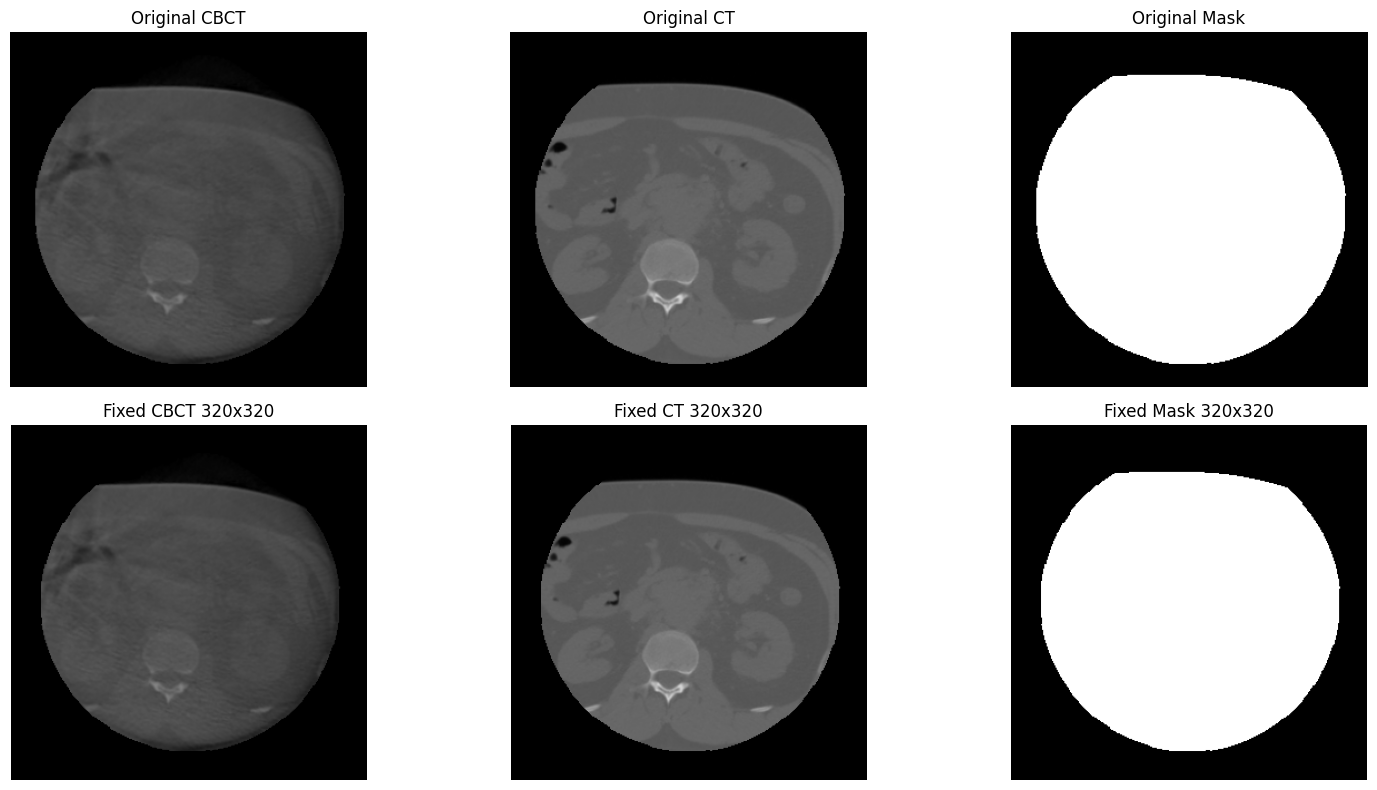

In [7]:
z = cbct.shape[0] // 2

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(cbct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Original CBCT")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Original CT")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mask[z], cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cbct_fixed[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Fixed CBCT 320x320")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ct_fixed[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Fixed CT 320x320")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(mask_fixed[z], cmap="gray")
plt.title("Fixed Mask 320x320")
plt.axis("off")

plt.tight_layout()
plt.show()

Region: AB
Patient: 2ABA002
Original shape: (88, 309, 310)
Fixed shape: (88, 320, 320)


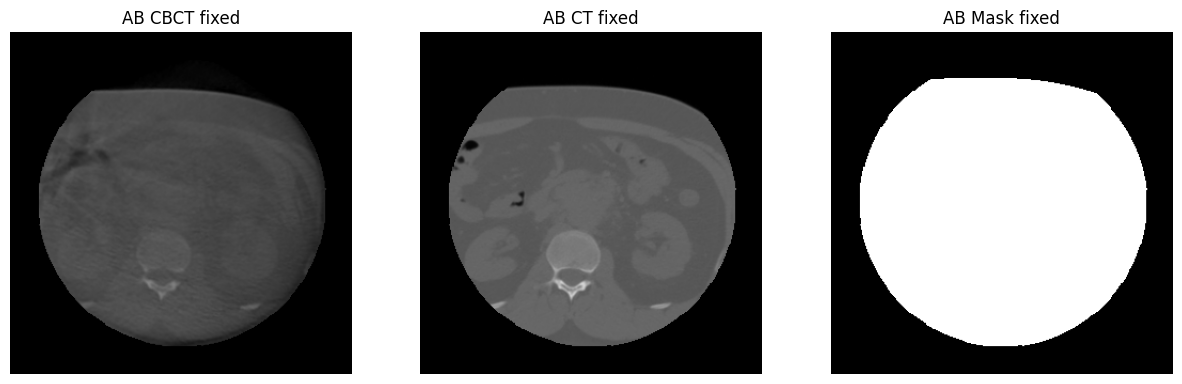

Region: HN
Patient: 2HNA002
Original shape: (88, 307, 309)
Fixed shape: (88, 320, 320)


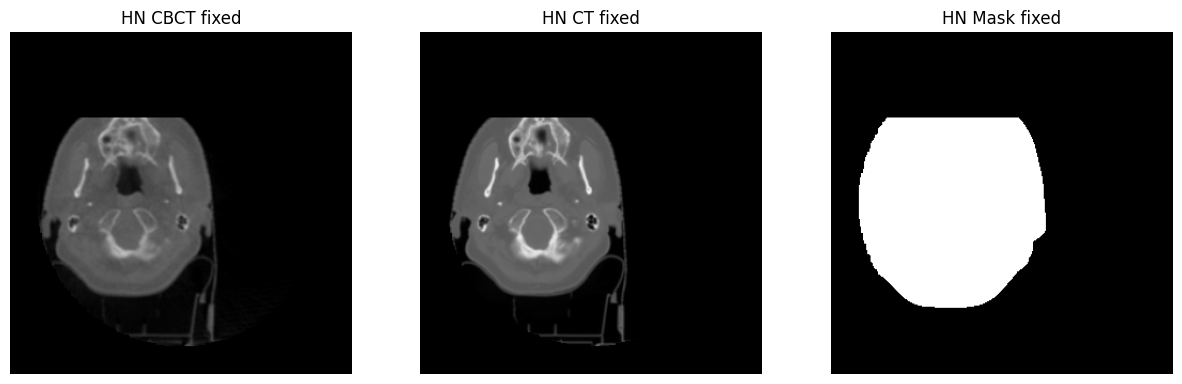

Region: TH
Patient: 2THA005
Original shape: (81, 311, 310)
Fixed shape: (81, 320, 320)


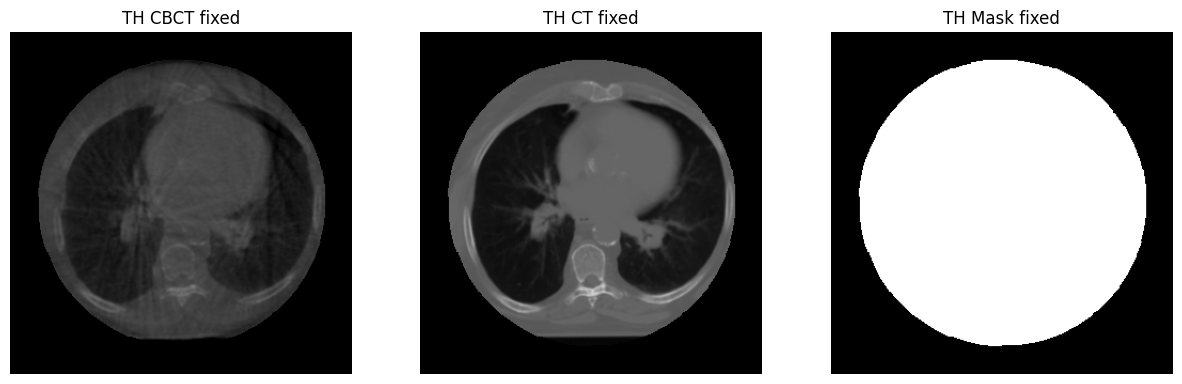

In [8]:
for region in ["AB", "HN", "TH"]:
    sample = df[df["region"] == region].iloc[0]

    _, cbct, _, _, _ = read_mha(sample["cbct_path"])
    _, ct, _, _, _ = read_mha(sample["ct_path"])
    _, mask, _, _, _ = read_mha(sample["mask_path"])

    mask = prepare_mask(mask)

    cbct_norm = normalize_hu(cbct)
    ct_norm = normalize_hu(ct)

    cbct_fixed = center_crop_or_pad_3d(cbct_norm, target_size=320, pad_value=-1)
    ct_fixed = center_crop_or_pad_3d(ct_norm, target_size=320, pad_value=-1)
    mask_fixed = center_crop_or_pad_3d(mask, target_size=320, pad_value=0)

    z = cbct.shape[0] // 2

    print("=" * 60)
    print("Region:", region)
    print("Patient:", sample["patient_id"])
    print("Original shape:", cbct.shape)
    print("Fixed shape:", cbct_fixed.shape)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cbct_fixed[z], cmap="gray", vmin=-1, vmax=1)
    plt.title(f"{region} CBCT fixed")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ct_fixed[z], cmap="gray", vmin=-1, vmax=1)
    plt.title(f"{region} CT fixed")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask_fixed[z], cmap="gray")
    plt.title(f"{region} Mask fixed")
    plt.axis("off")

    plt.show()

In [9]:
fixed_shapes = []

for i, row in df.iterrows():
    _, cbct, _, _, _ = read_mha(row["cbct_path"])

    cbct_fixed = center_crop_or_pad_3d(cbct, target_size=320, pad_value=-1000)

    fixed_shapes.append({
        "patient_id": row["patient_id"],
        "region": row["region"],
        "original_shape": str(cbct.shape),
        "fixed_shape": str(cbct_fixed.shape)
    })

fixed_df = pd.DataFrame(fixed_shapes)
print(fixed_df.head())
print(fixed_df["fixed_shape"].value_counts().head())

fixed_df.to_csv("data/fixed_shape_check.csv", index=False)

  patient_id region  original_shape     fixed_shape
0    2ABA002     AB  (88, 309, 310)  (88, 320, 320)
1    2ABA005     AB  (88, 309, 289)  (88, 320, 320)
2    2ABA006     AB  (87, 310, 312)  (87, 320, 320)
3    2ABA008     AB  (86, 308, 315)  (86, 320, 320)
4    2ABA009     AB  (87, 313, 311)  (87, 320, 320)
fixed_shape
(87, 320, 320)    158
(88, 320, 320)     94
(81, 320, 320)     83
(80, 320, 320)     59
(86, 320, 320)     48
Name: count, dtype: int64


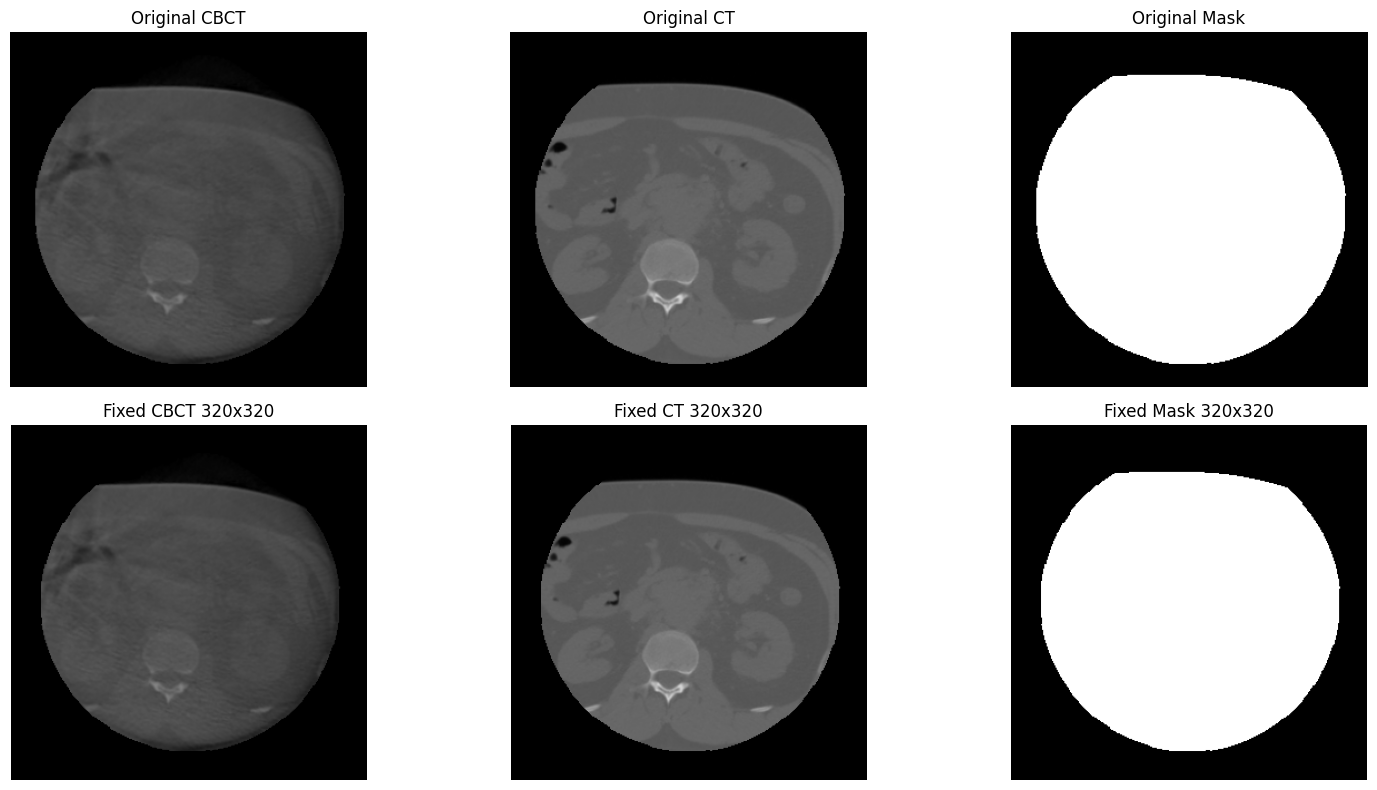

In [10]:
os.makedirs("results/figures/preprocessing_examples", exist_ok=True)

sample = df[df["region"] == "AB"].iloc[0]

_, cbct, _, _, _ = read_mha(sample["cbct_path"])
_, ct, _, _, _ = read_mha(sample["ct_path"])
_, mask, _, _, _ = read_mha(sample["mask_path"])

mask = prepare_mask(mask)
cbct_norm = normalize_hu(cbct)
ct_norm = normalize_hu(ct)

cbct_fixed = center_crop_or_pad_3d(cbct_norm, target_size=320, pad_value=-1)
ct_fixed = center_crop_or_pad_3d(ct_norm, target_size=320, pad_value=-1)
mask_fixed = center_crop_or_pad_3d(mask, target_size=320, pad_value=0)

z = cbct.shape[0] // 2

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(cbct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Original CBCT")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Original CT")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mask[z], cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cbct_fixed[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Fixed CBCT 320x320")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ct_fixed[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Fixed CT 320x320")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(mask_fixed[z], cmap="gray")
plt.title("Fixed Mask 320x320")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/preprocessing_examples/crop_pad_example.png", dpi=200)
plt.show()